# ExtraaLearn Project

## Context

The EdTech industry has been surging in the past decade immensely, and according to a forecast, the Online Education market would be worth $286.62bn by 2023 with a compound annual growth rate (CAGR) of 10.26% from 2018 to 2023. The modern era of online education has enforced a lot in its growth and expansion beyond any limit. Due to having many dominant features like ease of information sharing, personalized learning experience, transparency of assessment, etc, it is now preferable to traditional education.

In the present scenario due to the Covid-19, the online education sector has witnessed rapid growth and is attracting a lot of new customers. Due to this rapid growth, many new companies have emerged in this industry. With the availability and ease of use of digital marketing resources, companies can reach out to a wider audience with their offerings. The customers who show interest in these offerings are termed as leads. There are various sources of obtaining leads for Edtech companies, like

* The customer interacts with the marketing front on social media or other online platforms.
* The customer browses the website/app and downloads the brochure
* The customer connects through emails for more information.

The company then nurtures these leads and tries to convert them to paid customers. For this, the representative from the organization connects with the lead on call or through email to share further details.

## Objective

ExtraaLearn is an initial stage startup that offers programs on cutting-edge technologies to students and professionals to help them upskill/reskill. With a large number of leads being generated on a regular basis, one of the issues faced by ExtraaLearn is to identify which of the leads are more likely to convert so that they can allocate resources accordingly. You, as a data scientist at ExtraaLearn, have been provided the leads data to:
* Analyze and build an ML model to help identify which leads are more likely to convert to paid customers,
* Find the factors driving the lead conversion process
* Create a profile of the leads which are likely to convert


## Data Description

The data contains the different attributes of leads and their interaction details with ExtraaLearn. The detailed data dictionary is given below.


**Data Dictionary**
* ID: ID of the lead
* age: Age of the lead
* current_occupation: Current occupation of the lead. Values include 'Professional','Unemployed',and 'Student'
* first_interaction: How did the lead first interacted with ExtraaLearn. Values include 'Website', 'Mobile App'
* profile_completed: What percentage of profile has been filled by the lead on the website/mobile app. Values include Low - (0-50%), Medium - (50-75%), High (75-100%)
* website_visits: How many times has a lead visited the website
* time_spent_on_website: Total time spent on the website
* page_views_per_visit: Average number of pages on the website viewed during the visits.
* last_activity: Last interaction between the lead and ExtraaLearn.
    * Email Activity: Seeking for details about program through email, Representative shared information with lead like brochure of program , etc
    * Phone Activity: Had a Phone Conversation with representative, Had conversation over SMS with representative, etc
    * Website Activity: Interacted on live chat with representative, Updated profile on website, etc

* print_media_type1: Flag indicating whether the lead had seen the ad of ExtraaLearn in the Newspaper.
* print_media_type2: Flag indicating whether the lead had seen the ad of ExtraaLearn in the Magazine.
* digital_media: Flag indicating whether the lead had seen the ad of ExtraaLearn on the digital platforms.
* educational_channels: Flag indicating whether the lead had heard about ExtraaLearn in the education channels like online forums, discussion threads, educational websites, etc.
* referral: Flag indicating whether the lead had heard about ExtraaLearn through reference.
* status: Flag indicating whether the lead was converted to a paid customer or not.

## Importing necessary libraries and data

In [ ]:
# Importing Necessary Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, confusion_matrix

# Load the dataset
file_path = 'ExtraaLearn Data.csv'  # Replace with the correct path if needed
data = pd.read_csv(file_path)

# Display basic information about the dataset
print("Data Loaded Successfully!")

Data Loaded Successfully!


## Data Overview

- Observations
- Sanity checks

In [ ]:
## Data Overview
# Checking the shape of the Dataset
print(f"Dataset Shape: {data.shape}")

Dataset Shape: (4612, 15)


In [ ]:
# Display the first few rows of the dataset
data.head()

,ID,age,current_occupation,first_interaction,profile_completed,website_visits,time_spent_on_website,page_views_per_visit,last_activity,print_media_type1,print_media_type2,digital_media,educational_channels,referral,status
0,EXT001,57,Unemployed,Website,High,7,1639,1.861,Website Activity,Yes,No,Yes,No,No,1
1,EXT002,56,Professional,Mobile App,Medium,2,83,0.320,Website Activity,No,No,No,Yes,No,0
2,EXT003,52,Professional,Website,Medium,3,330,0.074,Website Activity,No,No,Yes,No,No,0
3,EXT004,53,Unemployed,Website,High,4,464,2.057,Website Activity,No,No,No,No,No,1
4,EXT005,23,Student,Website,High,4,600,16.914,Email Activity,No,No,No,No,No,0


In [ ]:
# Display the last few rows of the dataset
data.tail()

,ID,age,current_occupation,first_interaction,profile_completed,website_visits,time_spent_on_website,page_views_per_visit,last_activity,print_media_type1,print_media_type2,digital_media,educational_channels,referral,status
4607,EXT4608,35,Unemployed,Mobile App,Medium,15,360,2.170,Phone Activity,No,No,No,Yes,No,0
4608,EXT4609,55,Professional,Mobile App,Medium,8,2327,5.393,Email Activity,No,No,No,No,No,0
4609,EXT4610,58,Professional,Website,High,2,212,2.692,Email Activity,No,No,No,No,No,1
4610,EXT4611,57,Professional,Mobile App,Medium,1,154,3.879,Website Activity,Yes,No,No,No,No,0
4611,EXT4612,55,Professional,Website,Medium,4,2290,2.075,Phone Activity,No,No,No,No,No,0


In [ ]:
# Checking for duplicates in the data
print(f"Duplicate Rows: {data.duplicated().sum()}")

Duplicate Rows: 0


In [ ]:
# Checking for missing values in the data
round(data.isnull().sum() / data.isnull().count() * 100, 2)

,0
ID,0.0
age,0.0
current_occupation,0.0
first_interaction,0.0
profile_completed,0.0
website_visits,0.0
time_spent_on_website,0.0
page_views_per_visit,0.0
last_activity,0.0
print_media_type1,0.0


In [ ]:
# Checking the data types of the columns in the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4612 entries, 0 to 4611
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     4612 non-null   object 
 1   age                    4612 non-null   int64  
 2   current_occupation     4612 non-null   object 
 3   first_interaction      4612 non-null   object 
 4   profile_completed      4612 non-null   object 
 5   website_visits         4612 non-null   int64  
 6   time_spent_on_website  4612 non-null   int64  
 7   page_views_per_visit   4612 non-null   float64
 8   last_activity          4612 non-null   object 
 9   print_media_type1      4612 non-null   object 
 10  print_media_type2      4612 non-null   object 
 11  digital_media          4612 non-null   object 
 12  educational_channels   4612 non-null   object 
 13  referral               4612 non-null   object 
 14  status                 4612 non-null   int64  
dtypes: f

In [ ]:
# Convert appropriate columns to categorical datatypes
data['current_occupation'] = data['current_occupation'].astype('category')
data['first_interaction'] = data['first_interaction'].astype('category')
data['profile_completed'] = data['profile_completed'].astype('category')
data['last_activity'] = data['last_activity'].astype('category')
data['print_media_type1'] = data['print_media_type1'].astype('category')
data['print_media_type2'] = data['print_media_type2'].astype('category')
data['digital_media'] = data['digital_media'].astype('category')
data['educational_channels'] = data['educational_channels'].astype('category')
data['referral'] = data['referral'].astype('category')

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4612 entries, 0 to 4611
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   ID                     4612 non-null   object  
 1   age                    4612 non-null   int64   
 2   current_occupation     4612 non-null   category
 3   first_interaction      4612 non-null   category
 4   profile_completed      4612 non-null   category
 5   website_visits         4612 non-null   int64   
 6   time_spent_on_website  4612 non-null   int64   
 7   page_views_per_visit   4612 non-null   float64 
 8   last_activity          4612 non-null   category
 9   print_media_type1      4612 non-null   category
 10  print_media_type2      4612 non-null   category
 11  digital_media          4612 non-null   category
 12  educational_channels   4612 non-null   category
 13  referral               4612 non-null   category
 14  status                 4612 non-null   i

In [ ]:
# Obtaining the statistical summary of the numerical columns in the dataset
data.describe().T

,count,mean,std,min,25%,50%,75%,max
age,4612.0,46.201214,13.161454,18.0,36.00000,51.000,57.00000,63.000
website_visits,4612.0,3.566782,2.829134,0.0,2.00000,3.000,5.00000,30.000
time_spent_on_website,4612.0,724.011275,743.828683,0.0,148.75000,376.000,1336.75000,2537.000
page_views_per_visit,4612.0,3.026126,1.968125,0.0,2.07775,2.792,3.75625,18.434
status,4612.0,0.298569,0.457680,0.0,0.00000,0.000,1.00000,1.000


In [ ]:
# Creating the copy of the dataset
df = data.copy()

Observations and Sanity Checks
- The dataset has 4612 Rows and 15 Columns.
- The data has no duplicate rows.
- The data has no missing values.
- There are 9 category and 4 int type variables and 1 float and 1 object type variable.
- All the numerical columns have differing standrad deviations.
- The average age is 46, with the minimum age being 18 and maximum age being 63.
- The average number of website visits is between 3 and 4, with the minimum no. being 0 and maximum being 30.
- The average time spent on the website is 724 seconds, with the minimum time being 0s and maximum being 2537s.
- The average number of page views per website visit is 3, with the minimum no. being 0 and maximum being 18.
- Data type of columns are as expected and no unusual values (e.g negatives) in the statisrical summary.

## Exploratory Data Analysis (EDA)

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Questions**
1. Leads will have different expectations from the outcome of the course and the current occupation may play a key role in getting them to participate in the program. Find out how current occupation affects lead status.
2. The company's first impression on the customer must have an impact. Do the first channels of interaction have an impact on the lead status?
3. The company uses multiple modes to interact with prospects. Which way of interaction works best?
4. The company gets leads from various channels such as print media, digital media, referrals, etc. Which of these channels have the highest lead conversion rate?
5. People browsing the website or mobile application are generally required to create a profile by sharing their personal data before they can access additional information.Does having more details about a prospect increase the chances of conversion?

Univariate Analysis for Categorical Variables

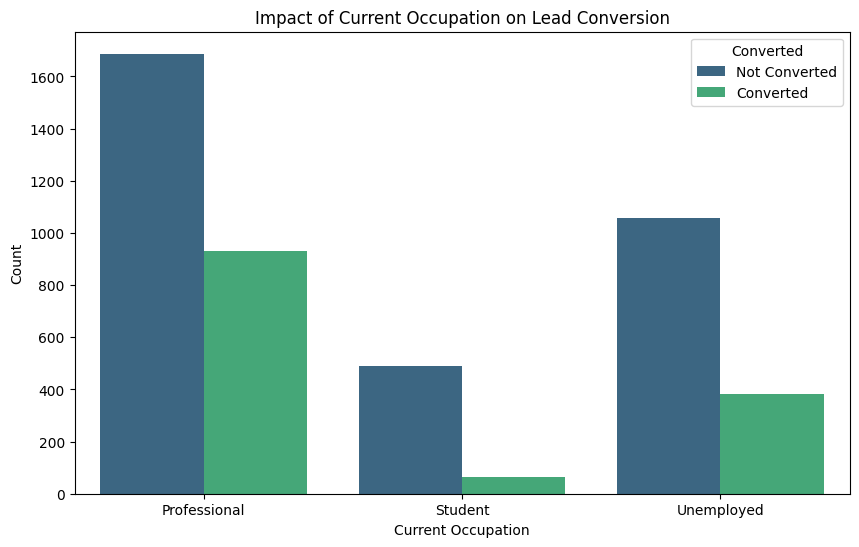

In [ ]:
## 1. Current Occupation vs Lead Status
plt.figure(figsize=(10, 6))
sns.countplot(data=data, x='current_occupation', hue='status', palette='viridis')
plt.title("Impact of Current Occupation on Lead Conversion")
plt.xlabel("Current Occupation")
plt.ylabel("Count")
plt.legend(title="Converted", labels=["Not Converted", "Converted"])
plt.show()

Observations:
- The largest group of leads comes from professionals.
- Among professionals, a significant proportion of leads are converted compared to other occupations.
- This indicates that professionals may have a higher interest or capability to invest in the program.
- Students constitute a smaller segment of leads.
- The conversion rate among students is low compared to professionals, suggesting that students may have budget constraints or different motivations.
- Unemployed individuals make up a moderate portion of leads.
- The conversion rate for this group is higher than that of students but lower than professionals.
- This group may be looking for upskilling opportunities, but financial constraints could limit conversions.
- Professionals are the most likely to convert: Programs targeting this group are more likely to yield higher conversions.
- Students and unemployed leads have lower conversion rates: These groups may require tailored approaches, such as scholarships, discounts, or flexible payment plans, to improve their conversion rates.

Actionable Insights:
- Focus marketing efforts on professionals, as they are more likely to convert.
- Create targeted campaigns or incentives for students and unemployed leads to improve their participation and conversion rates.

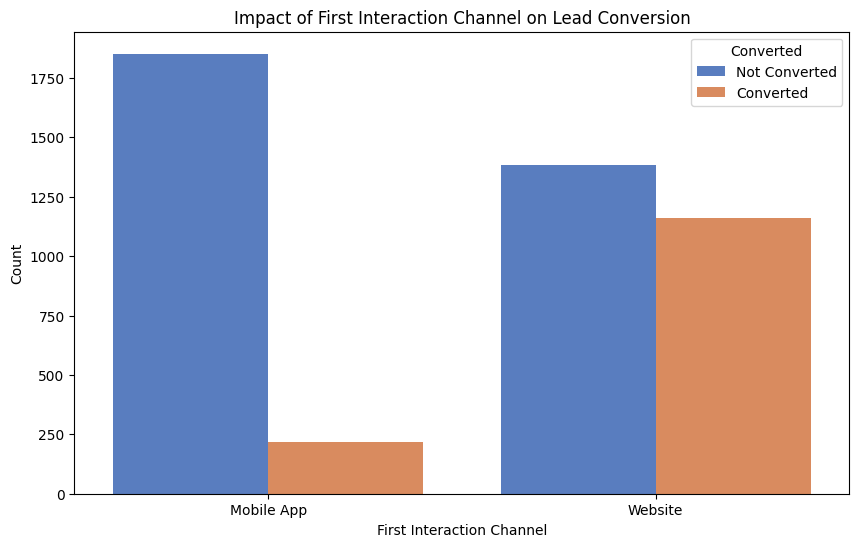

In [ ]:
## 2. First Interaction Channel vs Lead Status
plt.figure(figsize=(10, 6))
sns.countplot(data=data, x='first_interaction', hue='status', palette='muted')
plt.title("Impact of First Interaction Channel on Lead Conversion")
plt.xlabel("First Interaction Channel")
plt.ylabel("Count")
plt.legend(title="Converted", labels=["Not Converted", "Converted"])
plt.show()

Observations:
- Both avenues generate a similar number of leads.
- However, the proportion of converted leads from the mobile app is quite small compared to those who did not convert.
-This indicates that the mobile app may not be as effective in driving conversions despite generating a high volume of leads.
- The website has a significantly large portion of these leads converts, resulting in a noticeably higher conversion rate compared to the mobile app.
- This suggests that the website is better at attracting more qualified or interested leads.
- The Website has a greater impact on conversions.
- Leads that interact first through the website are likely more engaged or interested in the offering.
- The mobile app generates a large number of leads, but its low conversion rate suggests that many of these leads might not be seriously interested or fully engaged.

Actionable Insights:
- Investigate why the conversion rate for mobile app leads is low.
- Improving the user experience (UX) and engagement strategies.
- Adding personalized features or content to attract more serious leads.
- Ensure follow-ups and targeted marketing campaigns for mobile app leads to improve conversion.
- Invest more in website marketing and content strategy to further increase high-quality leads.
- Understand what aspects of the website experience are driving conversions (e.g., content layout, call-to-actions, FAQs) and replicate these features where possible.
- Encourage leads from the mobile app to visit the website for more in-depth information or to complete profile details. This might help convert casual leads into paying customers.

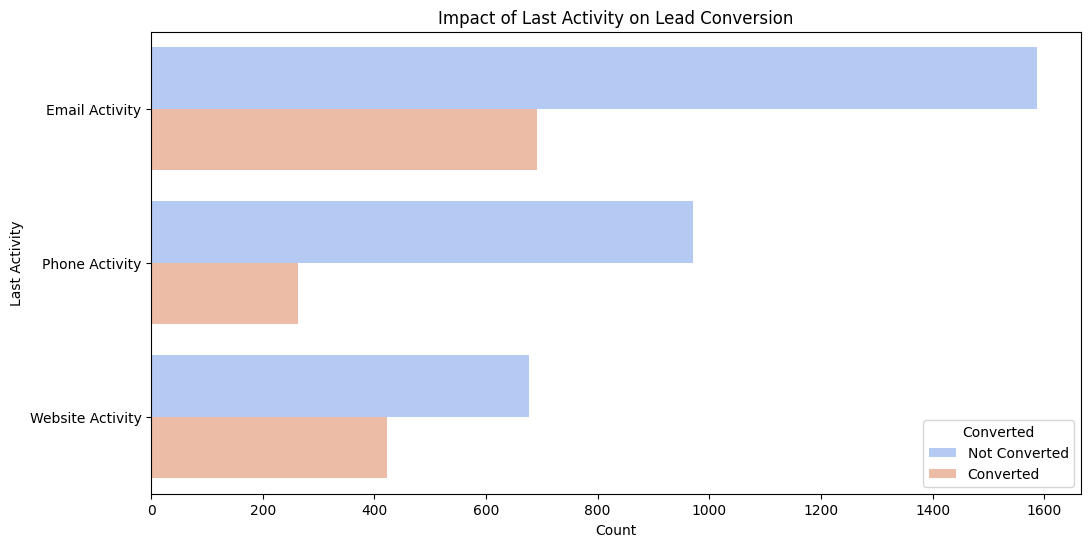

In [ ]:
## 3. Last Activity vs Lead Status
plt.figure(figsize=(12, 6))
sns.countplot(data=data, y='last_activity', hue='status', palette='coolwarm', order=data['last_activity'].value_counts().index)
plt.title("Impact of Last Activity on Lead Conversion")
plt.xlabel("Count")
plt.ylabel("Last Activity")
plt.legend(title="Converted", labels=["Not Converted", "Converted"])
plt.show()

Observations:

Email Activity:
- Email Activity is the most common last interaction mode.
- A significant proportion of these leads are not converted, indicating a lower effectiveness of emails in driving conversions.
- However, it still results in a moderate number of conversions due to its higher reach.
- While it is the most widely used mode, its low conversion rate suggests that emails might not be engaging or targeted enough to close leads effectively.

Phone Activity:
- Leads who interacted via Phone Activity have worst conversion rate compared to Email and Website Activity.
- The lower conversion ratio suggests that phone interactions are less effective in engaging prospects.
- Personalized interaction through phone calls or SMS might be found annoying and putting individuals off.

Website Activity:
- Website Activity shows a relatively higher conversion rate.
- Leads with Website Activity as the last interaction show a higher likelihood of being converted compared to Email and Phone Activity.
- Results suggest self-service options or real-time interactions on the website play a significant role in influencing decisions.

Actionable Insights:
- Cutback on phone activity as it is a waste of time and resources.
- Invest in scaling up website-based communication.
- Personalize website interactions using data from previous touchpoints.
- Improve live chat features, FAQs, and resources to encourage conversions.
- Optimize the website’s user experience for quick access to critical information.
- Make emails more targeted and personalized based on the lead’s profile and activity history.
- Use A/B testing to optimize subject lines, content, and call-to-action buttons to increase engagement and conversion rates.




<ipython-input-16-24e095aa5416>:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  conversion_rate = data.groupby(channel)['status'].mean()
<ipython-input-16-24e095aa5416>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(channel_conversion_rates.keys()), y=list(channel_conversion_rates.values()), palette='pastel')


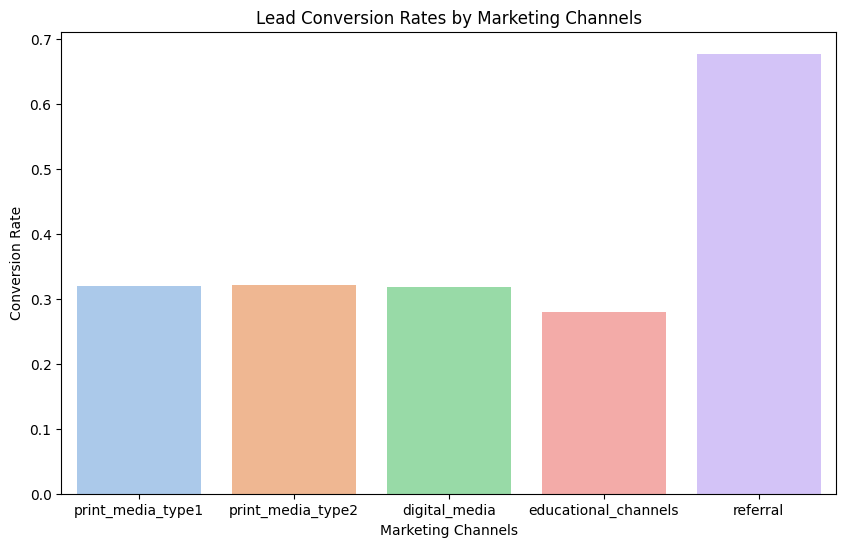

In [ ]:
## 4. Lead Conversion by Marketing Channels
marketing_channels = ['print_media_type1', 'print_media_type2', 'digital_media', 'educational_channels', 'referral']

channel_conversion_rates = {}
for channel in marketing_channels:
    if channel in data.columns:
        conversion_rate = data.groupby(channel)['status'].mean()
        channel_conversion_rates[channel] = conversion_rate.get('Yes', 0)

# Plot conversion rates
plt.figure(figsize=(10, 6))
sns.barplot(x=list(channel_conversion_rates.keys()), y=list(channel_conversion_rates.values()), palette='pastel')
plt.title("Lead Conversion Rates by Marketing Channels")
plt.xlabel("Marketing Channels")
plt.ylabel("Conversion Rate")
plt.show()

Observations:

Referral:
- Referrals have the highest conversion rate among all channels, significantly outperforming other sources.
- This indicates that leads generated through referrals are more likely to trust the company and convert into paying customers.

Print Media Type 1 and Type 2:
- Both print media channels (e.g., newspapers, magazines) have a moderate conversion rate of around 30%.
- These channels contribute to conversions but are not as impactful as referrals.

Digital Media:
- Digital media also shows a moderate conversion rate, slightly above educational channels.
- This suggests that digital ads and platforms bring in moderately engaged leads.

Educational Channels:
- Educational channels (e.g., forums, discussion threads) have the lowest conversion rate.
- This might indicate that leads from these sources are less likely to take actionable steps or convert.

Overview
Referrals are the most effective:
- Leads generated via referrals have a high trust factor and a higher likelihood of conversion.
- This makes referrals the most valuable marketing channel for the company.

Print Media and Digital Media are moderately effective:
- These channels generate leads with decent conversion rates but require further optimization to close more leads.

Educational Channels need improvement:
- Leads from educational channels are less likely to convert, indicating that this channel may need better targeting or follow-up strategies.

Actionable Insights:
Invest in Referral Programs:
- Strengthen referral programs to encourage more satisfied customers to recommend the service.
- Offer incentives or rewards for successful referrals to increase participation.

Optimize Print Media and Digital Campaigns:
- Analyze the effectiveness of specific ads or content formats in these channels.
- Target more qualified audiences to improve conversion rates.

Reassess Educational Channels:
- Evaluate why educational channels are underperforming.
- Improve content or engagement strategies, such as interactive webinars or partnerships with trusted educational platforms.

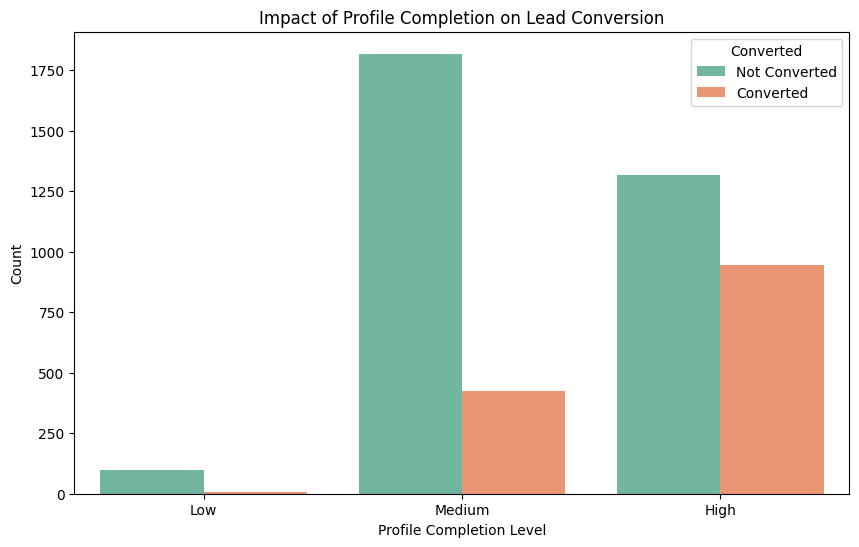

In [ ]:
## 5. Profile Completion vs Lead Status
plt.figure(figsize=(10, 6))
sns.countplot(data=data, x='profile_completed', hue='status', palette='Set2', order=['Low', 'Medium', 'High'])
plt.title("Impact of Profile Completion on Lead Conversion")
plt.xlabel("Profile Completion Level")
plt.ylabel("Count")
plt.legend(title="Converted", labels=["Not Converted", "Converted"])
plt.show()

Univariate Analysis for Numerical Variables

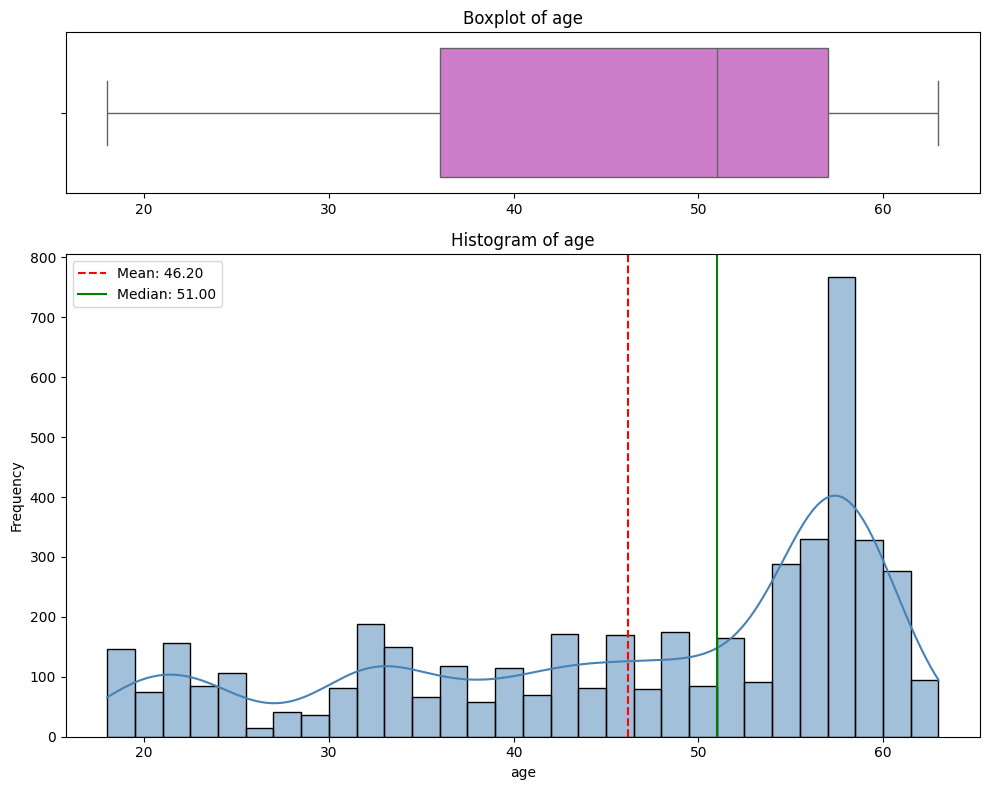

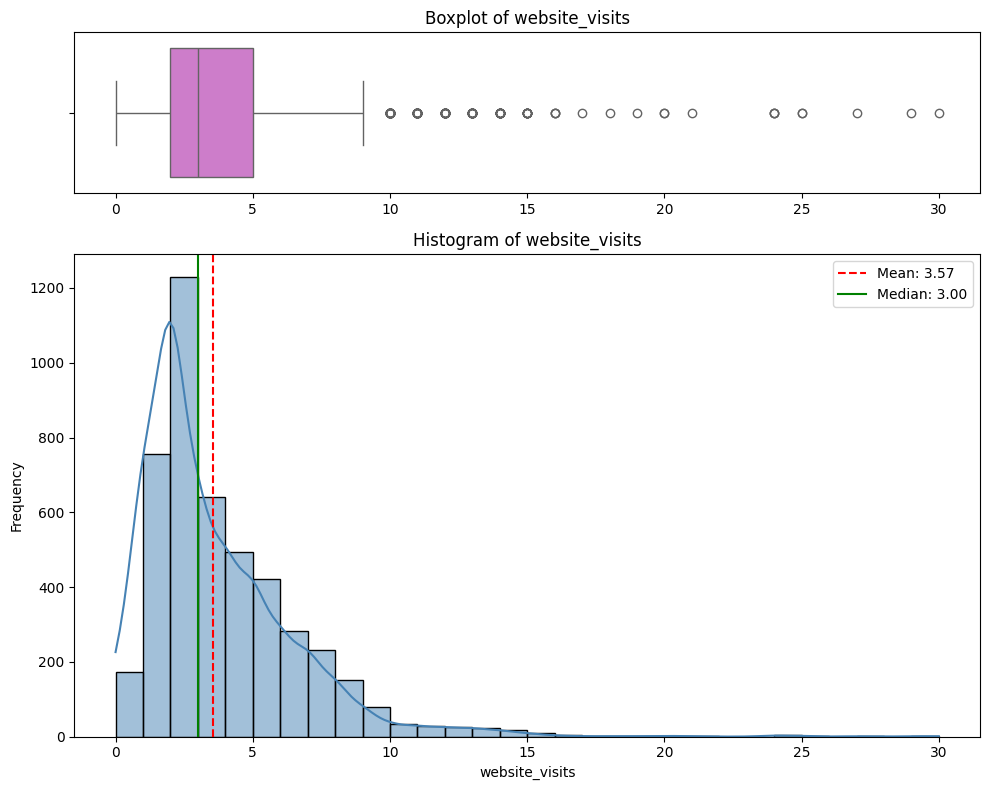

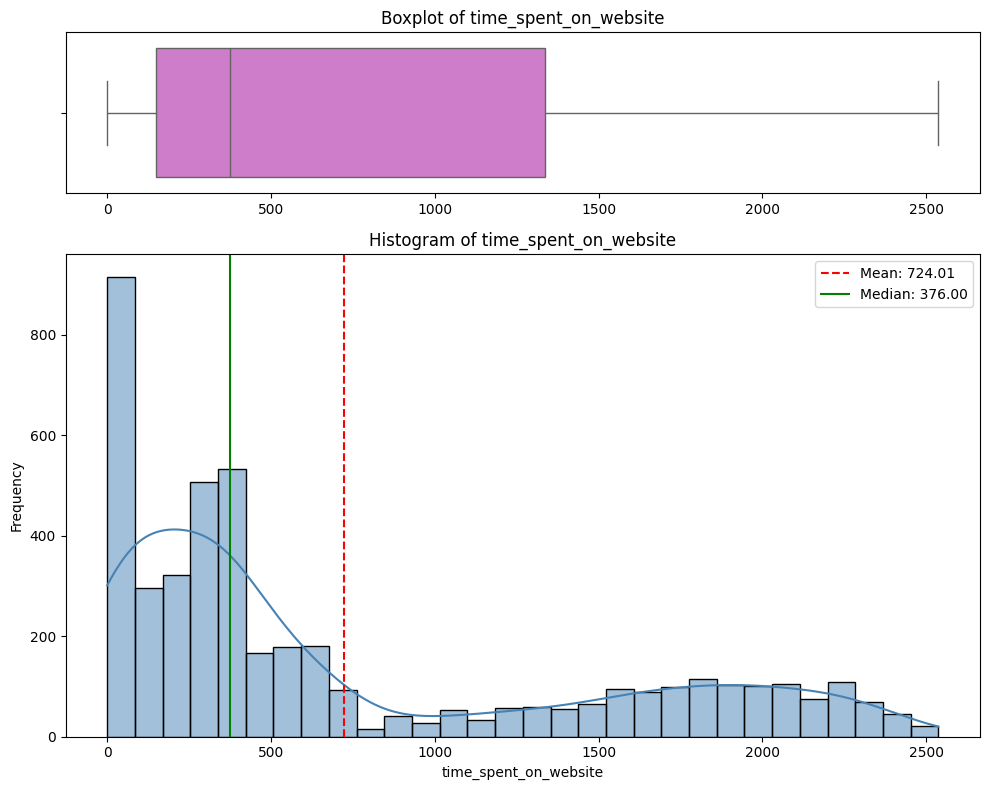

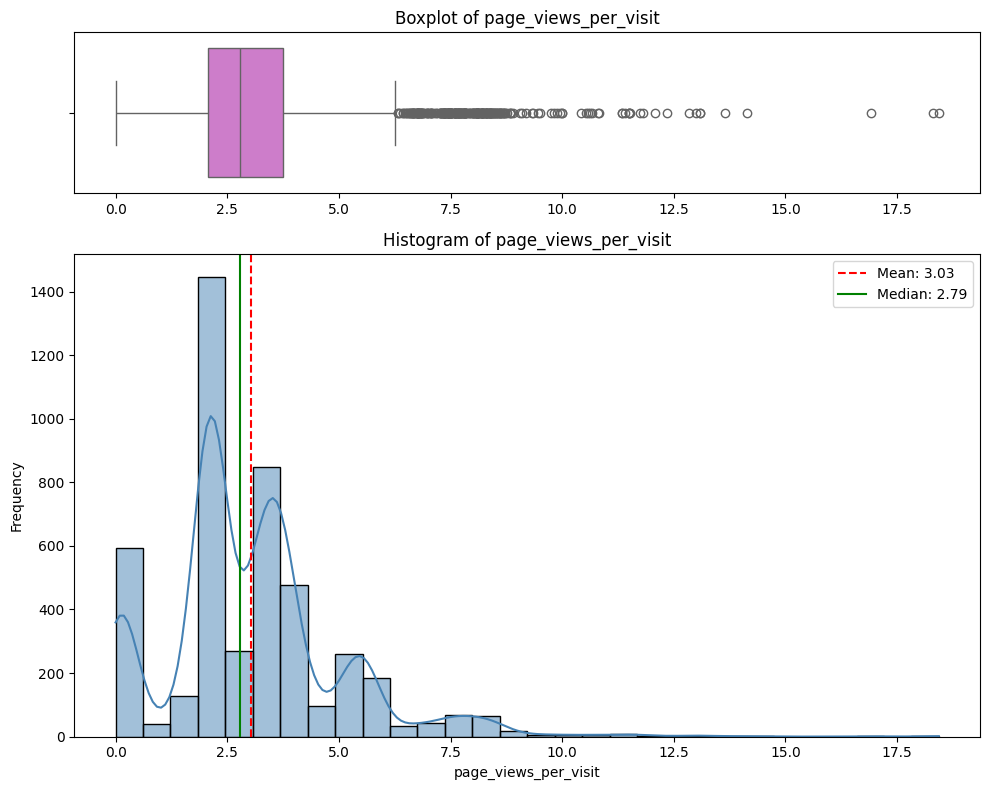

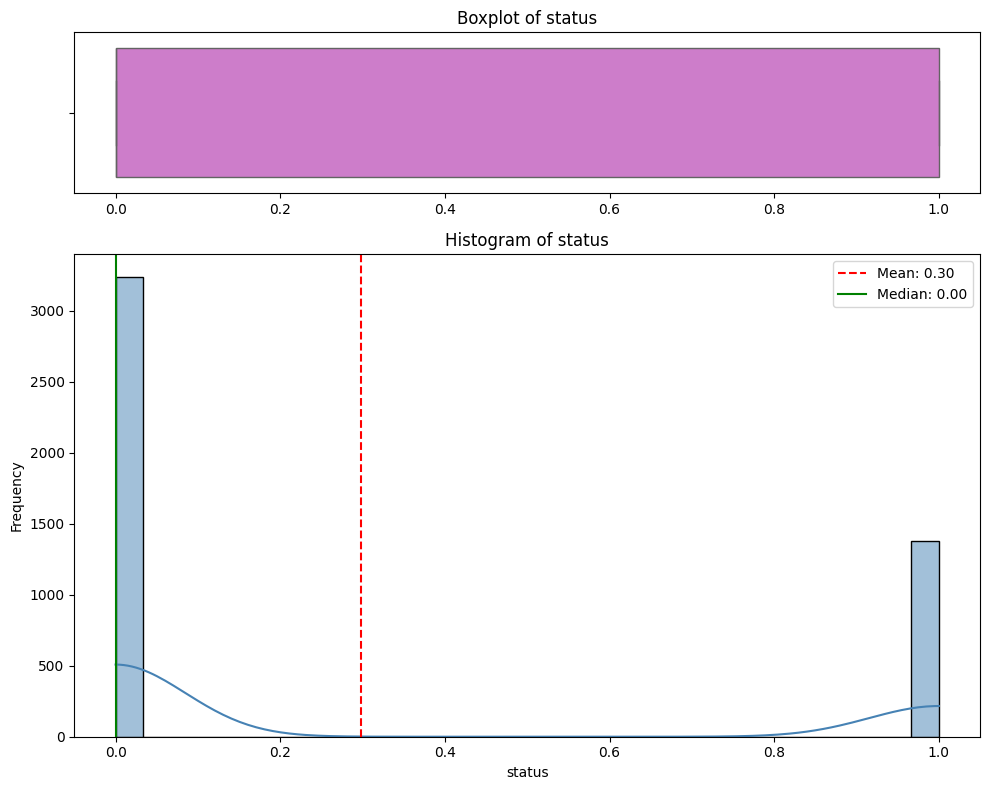

In [ ]:
# Univariate Analysis for Numerical Variables
numerical_cols = data.select_dtypes(include=['int64', 'float64']).columns

for col in numerical_cols:
    fig, axes = plt.subplots(2, 1, figsize=(10, 8), gridspec_kw={'height_ratios': [1, 3]})

    # Boxplot
    sns.boxplot(data=data, x=col, ax=axes[0], color='orchid')
    axes[0].set_title(f"Boxplot of {col}")
    axes[0].set_xlabel("")
    axes[0].grid(False)

    # Histogram with mean and median
    sns.histplot(data=data, x=col, kde=True, ax=axes[1], bins=30, color='steelblue')
    mean_value = data[col].mean()
    median_value = data[col].median()
    axes[1].axvline(mean_value, color='red', linestyle='--', label=f"Mean: {mean_value:.2f}")
    axes[1].axvline(median_value, color='green', linestyle='-', label=f"Median: {median_value:.2f}")
    axes[1].set_title(f"Histogram of {col}")
    axes[1].set_xlabel(col)
    axes[1].set_ylabel("Frequency")
    axes[1].legend()

    # Adjust layout for better spacing
    plt.tight_layout()
    plt.show()

Observations:

Age Demographic:
- Mean: 46.20 years; Median: 51.00 years.
- The age distribution shows a slight right skew, with the median being higher than the mean.
- Most of the leads are clustered around the age of 50, indicating that middle-aged individuals form the majority of the audience.
- There are no significant outliers, and the range is between 18 and 63 years.

Number of Website Visits:
- Mean: 3.57 visits; Median: 3 visits.
- The distribution is highly right-skewed, with most leads visiting the website 0-5 times.
- There are a few outliers where leads have visited the website up to 30 times, suggesting high engagement for these individuals.
- The majority of leads have low website visits, indicating room for strategies to encourage repeated visits.

Time Spent on Website:
- Mean: 724.01 seconds; Median: 376.00 seconds.
- The distribution is heavily right-skewed, with many leads spending minimal time (under 500 seconds) on the website.
- A small portion of users spends a significant amount of time (up to 2500 seconds), indicating high engagement.
- The gap between the mean and median suggests that a few highly engaged leads are skewing the average.

Page Views per Website Visit:
- Mean: 3.03 pages; Median: 2.79 pages.
- The distribution is moderately right-skewed, with most leads viewing 2-3 pages per visit.
- There are outliers with leads viewing up to 17 pages per visit, representing highly engaged users.
- The majority of leads view only a few pages, suggesting that improving page engagement could increase conversions.

General Insights:
- Age: The audience is primarily middle-aged, indicating a need to tailor marketing and program offerings for this demographic.
- Website Visits: While most leads have few visits, the outliers with many visits might represent highly engaged potential customers.
- Time Spent on Website: Efforts to increase engagement time for leads spending minimal time could improve conversions.
- Page Views per Visit: Optimizing website content to encourage more page exploration could enhance user engagement and interest.

Bivariate Analysis: Numerical Variables Vs Lead Conversion Status

<ipython-input-25-33837ce50491>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='status', y=col, palette='Set2')


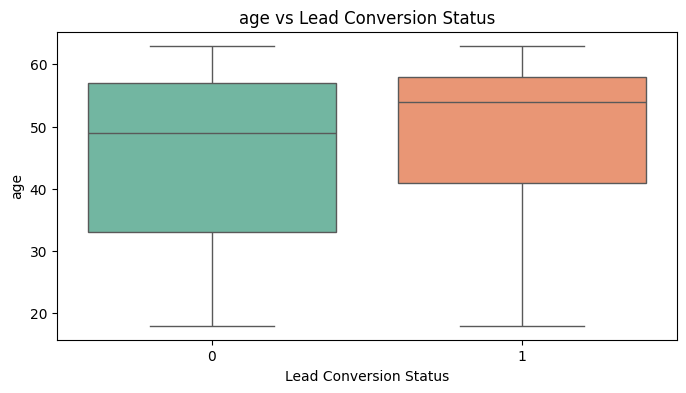

<ipython-input-25-33837ce50491>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='status', y=col, palette='Set2')


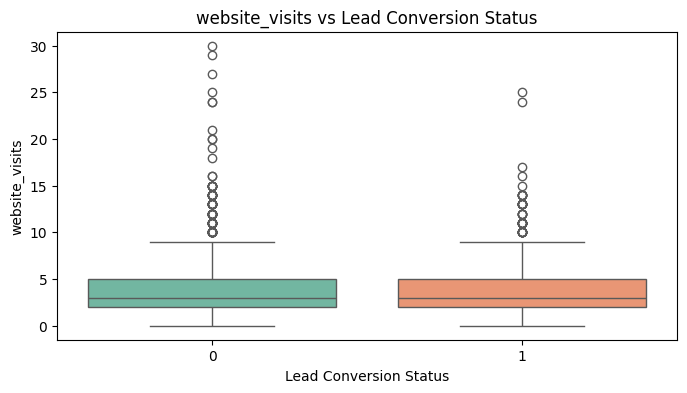

<ipython-input-25-33837ce50491>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='status', y=col, palette='Set2')


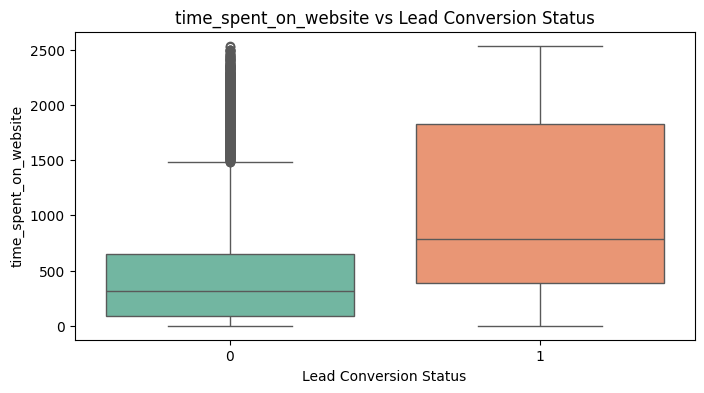

<ipython-input-25-33837ce50491>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='status', y=col, palette='Set2')


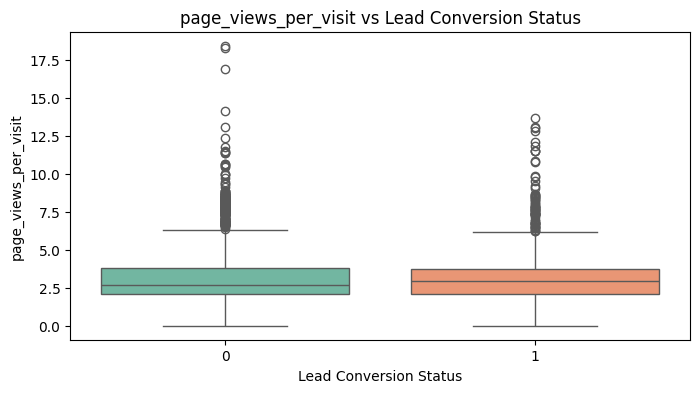

<ipython-input-25-33837ce50491>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='status', y=col, palette='Set2')


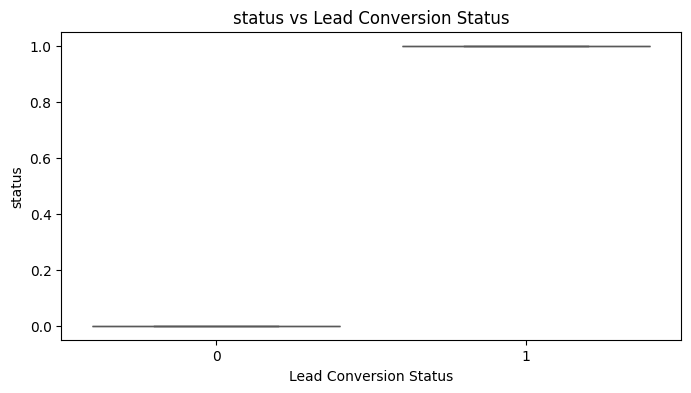

In [ ]:
# Bivariate Analysis: Numerical Variables vs Lead Conversion Status
numerical_cols = data.select_dtypes(include=['int64', 'float64']).columns

for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=data, x='status', y=col, palette='Set2')
    plt.title(f"{col} vs Lead Conversion Status")
    plt.xlabel("Lead Conversion Status")
    plt.ylabel(col)
    plt.show()

Observations:
Age Demographic vs. Lead Conversion Status:

Converted Leads (Status = 1):
- Tend to have a higher median age compared to non-converted leads.
- The range of ages for converted leads skews older, with fewer younger participants converting.

Non-Converted Leads (Status = 0):
- Show a broader age range with more younger leads compared to converted leads.
Key Insight:
- Older individuals are more likely to convert, possibly due to greater financial stability or a clearer focus on upskilling goals.

Number of Website Visits vs. Lead Conversion Status:

Converted Leads:
- Have a slightly lower median for website visits compared to non-converted leads.
- There are fewer outliers in the number of visits for converted leads, indicating that high website visits are not a significant predictor of conversion.

Non-Converted Leads:
- Show a slightly higher number of visits with more outliers (extremely high visits without converting).

Key Insight:
- Excessive website visits may not correlate with higher conversion rates, as engaged leads tend to convert with fewer visits.

Time Spent on Website vs. Lead Conversion Status:

Converted Leads:
- Spend significantly more time on the website (higher median and range) compared to non-converted leads.
- The higher time spent suggests greater engagement and intent.

Non-Converted Leads:
- Spend minimal time on the website, with several outliers for higher engagement that did not result in conversion.

Key Insight:
- Time spent on the website is positively correlated with conversion, making it a strong engagement metric.

Page Views per Website Visit vs. Lead Conversion Status:

Converted Leads:
- Tend to view slightly more pages per visit (higher median) than non-converted leads.
- There is overlap in page views between converted and non-converted leads, but higher page views slightly favor conversions.

Non-Converted Leads:
- Have a lower median for page views, with more extreme outliers for leads with very high page views that do not convert.

Key Insight:
- While page views per visit contribute to engagement, they are not a definitive predictor of conversion on their own.

Correlation Heatmap for Numerical Variables

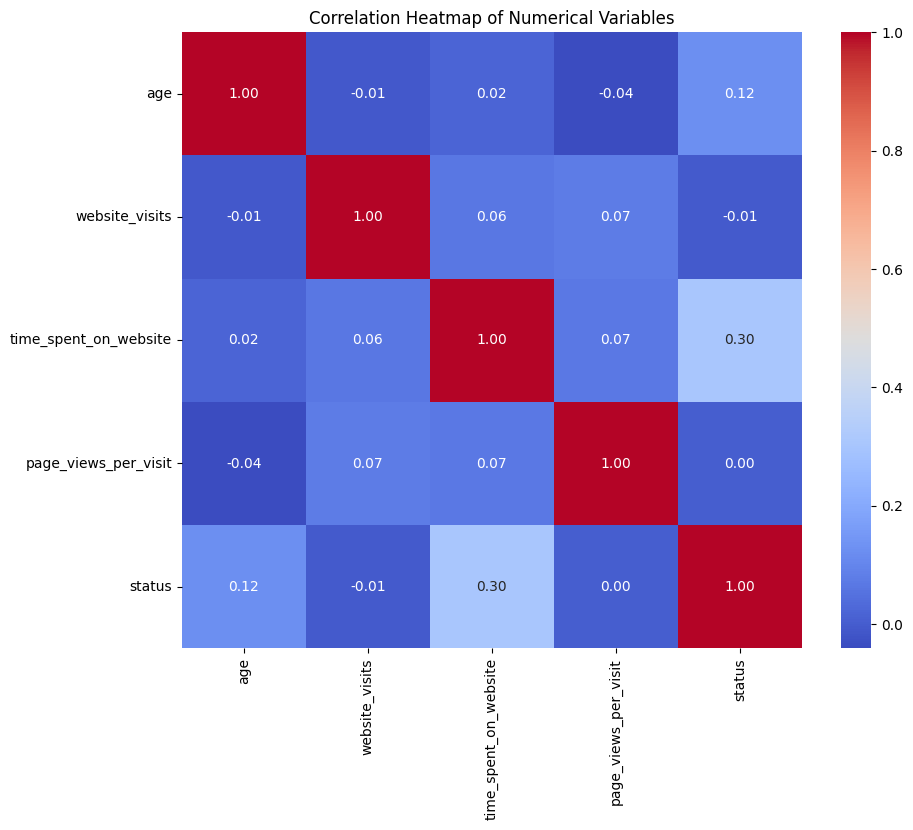

In [ ]:
# Correlation Heatmap for Numerical Variables
plt.figure(figsize=(10, 8))
sns.heatmap(data[numerical_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Heatmap of Numerical Variables")
plt.show()

Observations:

Strongest Positive Correlation:
- Time spent on website shows the strongest correlation with status (Lead Conversion), with a value of 0.30.

Age:
- Shows a weak positive correlation with status (0.12), indicating low influence on conversion rates.

Other Metrics:
- Website visits and Page views per visit show negligible correlations with status (-0.01 and 0.00, respectively).
- These metrics alone may not be significant predictors of conversion but could contribute when combined with other factors.

## Data Preprocessing

- Missing value treatment (if needed)
- Feature engineering (if needed)
- Outlier detection and treatment (if needed)
- Preparing data for modeling
- Any other preprocessing steps (if needed)

In [ ]:
# Import necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [ ]:
# Create a copy of the dataframe
df1 = df.copy()

In [ ]:
# 1. Separate Features and Target Variable
X = data.drop(columns=['ID', 'status'])  # Dropping ID and status columns
y = data['status']  # Target variable

# 2. Identify Numerical and Categorical Columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X.select_dtypes(include=['object', 'category']).columns

# 3. Define Preprocessing for Numerical Features
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())  # Standardizes numerical columns
])

# 4. Define Preprocessing for Categorical Features
categorical_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore'))  # Encodes categorical variables
])

# 5. Combine Preprocessing in a ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

# 6. Split Data into Training and Test Sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 7. Apply Preprocessing
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# 8. Print Preprocessing Summary
print("Data Preprocessing Completed")
print(f"Numerical Columns: {numerical_cols.tolist()}")
print(f"Categorical Columns: {categorical_cols.tolist()}")
print(f"Processed Training Data Shape: {X_train_processed.shape}")
print(f"Processed Test Data Shape: {X_test_processed.shape}")

Data Preprocessing Completed
Numerical Columns: ['age', 'website_visits', 'time_spent_on_website', 'page_views_per_visit']
Categorical Columns: ['current_occupation', 'first_interaction', 'profile_completed', 'last_activity', 'print_media_type1', 'print_media_type2', 'digital_media', 'educational_channels', 'referral']
Processed Training Data Shape: (3689, 25)
Processed Test Data Shape: (923, 25)


## Building a Decision Tree model

In [ ]:
# Import libraries for model building and evaluation
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, confusion_matrix
from sklearn import tree
import matplotlib.pyplot as plt

In [ ]:
#Initialize the Decision Tree Classifier
decision_tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=5,  # Controls tree depth for simplicity
    criterion='gini'  # Gini Impurity for splits
)

In [ ]:
# Train the model on preprocessed training data
decision_tree.fit(X_train_processed, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [ ]:
# Make Predictions
y_pred = decision_tree.predict(X_test_processed)  # Predictions for test data
y_pred_proba = decision_tree.predict_proba(X_test_processed)[:, 1]  # Probabilities for ROC-AUC

## Model Performance evaluation and improvement

Model Performance

In [ ]:
# Evaluate Model Performance
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("Decision Tree Model Performance:")
print(f"Accuracy: {accuracy:.2f}")
print(f"ROC-AUC: {roc_auc:.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Decision Tree Model Performance:
Accuracy: 0.86
ROC-AUC: 0.93

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.91      0.90       647
           1       0.79      0.73      0.76       276

    accuracy                           0.86       923
   macro avg       0.84      0.82      0.83       923
weighted avg       0.86      0.86      0.86       923



Observations:
- ROC-AUC score of 0.93 suggests excellent separability, meaning the model is quite good at ranking predictions.
- The lower recall for class 1 suggests the model struggles to identify all converted leads.
- The high ROC-AUC score (0.93) compared to recall for the minority class (1) indicates that while the model distinguishes classes well, it may overfit to patterns in the training data.

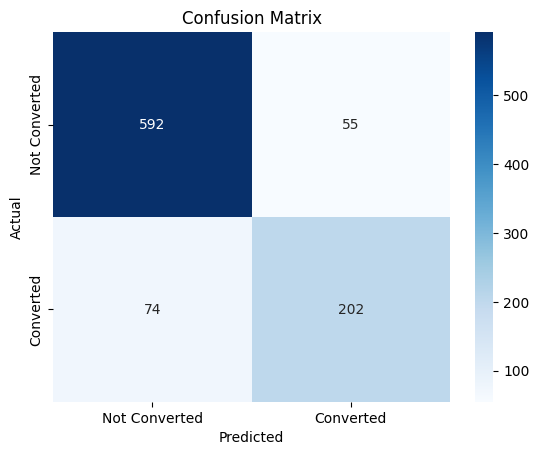

In [ ]:
# Confusion Matrix Visualization
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Converted', 'Converted'], yticklabels=['Not Converted', 'Converted'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

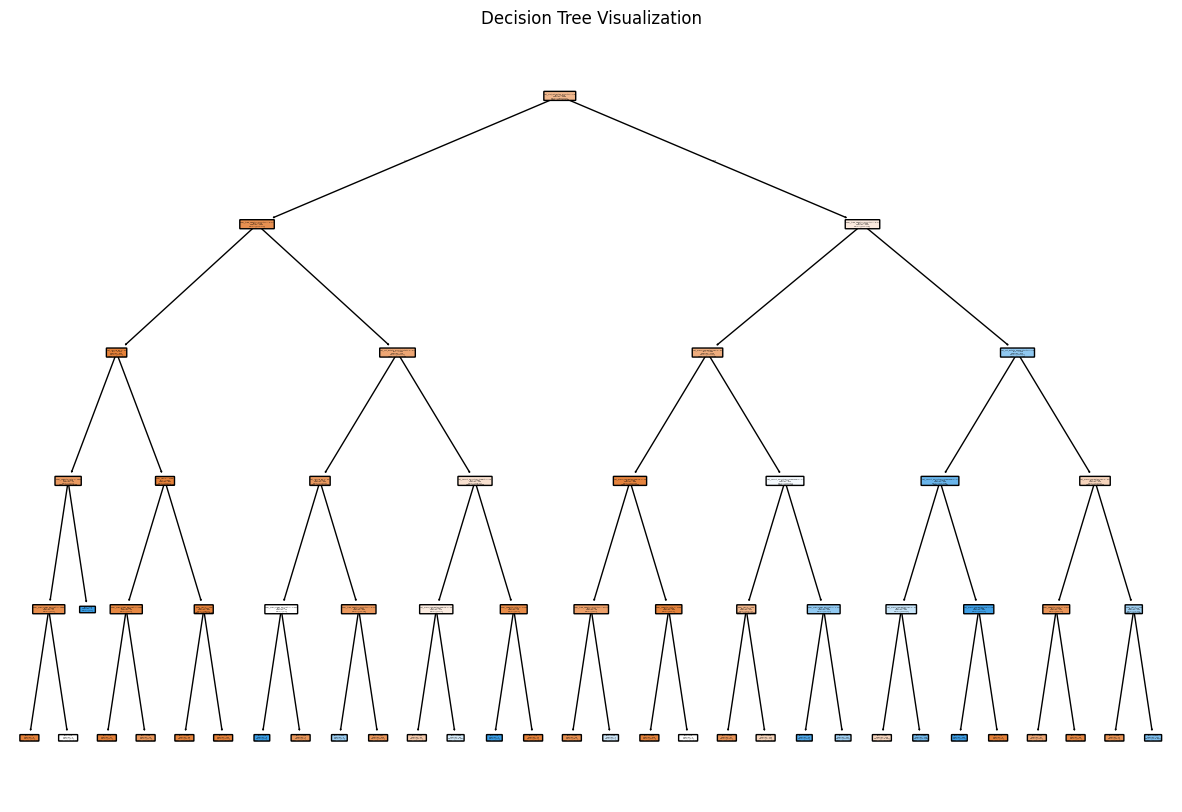

In [ ]:
# Decision Tree Visualization
plt.figure(figsize=(15, 10))
tree.plot_tree(
    decision_tree,
    feature_names=preprocessor.get_feature_names_out(),
    class_names=['Not Converted', 'Converted'],
    filled=True,
    rounded=True
)
plt.title("Decision Tree Visualization")
plt.show()

Model Improvement

In [ ]:
# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

# Define hyperparameter grid
param_grid = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'criterion': ['gini', 'entropy']
}

# Initialize Grid Search
grid_search = GridSearchCV(estimator=DecisionTreeClassifier(random_state=42),
                           param_grid=param_grid,
                           scoring='roc_auc',
                           cv=5,
                           verbose=1)

# Fit Grid Search to the data
grid_search.fit(X_train_processed, y_train)

# Best Parameters
print("Best Hyperparameters:", grid_search.best_params_)

# Evaluate the tuned model
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test_processed)
y_pred_proba_tuned = best_model.predict_proba(X_test_processed)[:, 1]

print("\nTuned Model Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_tuned):.2f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_tuned):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned))

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Hyperparameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 10}

Tuned Model Performance:
Accuracy: 0.86
ROC-AUC: 0.93

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.91      0.90       647
           1       0.79      0.73      0.76       276

    accuracy                           0.86       923
   macro avg       0.84      0.82      0.83       923
weighted avg       0.86      0.86      0.86       923



Observations:
- No significant change in performance, however confirmed original models robustness.

In [ ]:
# Address Class Imbalance
balanced_model = DecisionTreeClassifier(random_state=42, class_weight='balanced', max_depth=5)
balanced_model.fit(X_train_processed, y_train)

y_pred_balanced = balanced_model.predict(X_test_processed)
y_pred_proba_balanced = balanced_model.predict_proba(X_test_processed)[:, 1]

print("\nBalanced Model Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_balanced):.2f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_balanced):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_balanced))


Balanced Model Performance:
Accuracy: 0.84
ROC-AUC: 0.93

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.82      0.88       647
           1       0.68      0.87      0.76       276

    accuracy                           0.84       923
   macro avg       0.81      0.84      0.82       923
weighted avg       0.86      0.84      0.84       923



Observations:
- Addressing the class imbalance improved recall for class 1 (converted leads) at the expense of precision and recall for class 0.
- This is a favorable outcome in this context, as identifying converted leads (class 1) is often more critical than maintaining high accuracy for non-converted leads (class 0).
- The balanced model is better at identifying converted leads, which is likely the primary goal of the business.
- The slight drop in accuracy is acceptable, given the significant improvement in identifying the minority class.

## Building a Random Forest model

In [ ]:
# Import necessary libraries
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Initialize the Random Forest Classifier
rf_model = RandomForestClassifier(
    random_state=42,
    n_estimators=100,  # Number of trees in the forest
    max_depth=10,  # Maximum depth of each tree
    min_samples_split=5,  # Minimum samples required to split an internal node
    min_samples_leaf=2,  # Minimum samples required to be at a leaf node
    criterion='gini'  # Splitting criterion
)

In [ ]:
# Train the Random Forest model
rf_model.fit(X_train_processed, y_train)

RandomForestClassifier(max_depth=10, min_samples_leaf=2, min_samples_split=5,
                       random_state=42)

In [ ]:
# Predictions on the test set
y_pred_rf = rf_model.predict(X_test_processed)
y_pred_proba_rf = rf_model.predict_proba(X_test_processed)[:, 1]

## Model Performance evaluation and improvement

Model Performance

In [ ]:
# Evaluate the Random Forest model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)

print("Random Forest Model Performance:")
print(f"Accuracy: {accuracy_rf:.2f}")
print(f"ROC-AUC: {roc_auc_rf:.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Model Performance:
Accuracy: 0.87
ROC-AUC: 0.93

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.93      0.91       647
           1       0.81      0.75      0.78       276

    accuracy                           0.87       923
   macro avg       0.85      0.84      0.84       923
weighted avg       0.87      0.87      0.87       923



Observations:
- Metrics like accuracy (0.87) and ROC-AUC (0.93) are high, but there is no dramatic gap between class 1 recall and overall accuracy. Thus suggests model is not overfitting.
- Strong balance across metrics; slightly better than decision tree.

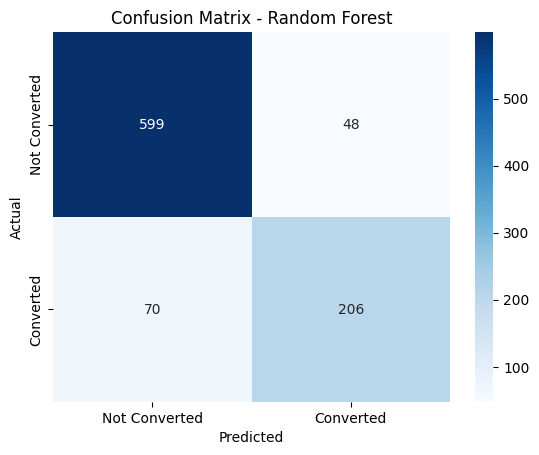

In [ ]:
# Confusion Matrix Visualization
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Converted', 'Converted'], yticklabels=['Not Converted', 'Converted'])
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

<ipython-input-46-f5e3951f9ae6>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df_rf.head(10), x='Importance', y='Feature', palette='viridis')


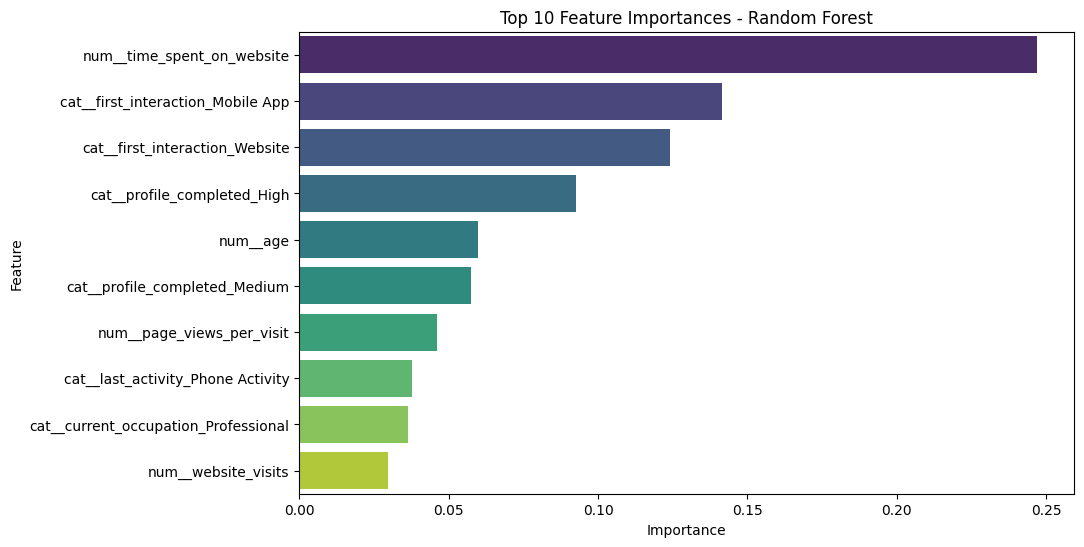

In [ ]:
# Feature Importance Visualization
feature_importances = rf_model.feature_importances_
features = preprocessor.get_feature_names_out()
importance_df_rf = pd.DataFrame({'Feature': features, 'Importance': feature_importances})
importance_df_rf = importance_df_rf.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df_rf.head(10), x='Importance', y='Feature', palette='viridis')
plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

Model Improvement

In [ ]:
# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

# Define the hyperparameter grid
param_grid_rf = {
    'n_estimators': [100, 200, 300],  # Number of trees
    'max_depth': [10, 15, 20, None],  # Maximum depth of trees
    'min_samples_split': [2, 5, 10],  # Minimum samples required to split a node
    'min_samples_leaf': [1, 2, 4],  # Minimum samples at a leaf node
    'criterion': ['gini', 'entropy']  # Splitting criteria
}

# Initialize Grid Search
grid_search_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf,
    scoring='roc_auc',
    cv=5,
    verbose=1,
    n_jobs=-1
)

# Fit Grid Search
grid_search_rf.fit(X_train_processed, y_train)

# Best Parameters
print("Best Hyperparameters:", grid_search_rf.best_params_)

# Evaluate the tuned model
best_rf_model = grid_search_rf.best_estimator_
y_pred_tuned_rf = best_rf_model.predict(X_test_processed)
y_pred_proba_tuned_rf = best_rf_model.predict_proba(X_test_processed)[:, 1]

print("\nTuned Random Forest Model Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_tuned_rf):.2f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_tuned_rf):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned_rf))

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


/usr/local/lib/python3.10/dist-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Best Hyperparameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 300}

Tuned Random Forest Model Performance:
Accuracy: 0.87
ROC-AUC: 0.93

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.93      0.91       647
           1       0.82      0.74      0.78       276

    accuracy                           0.87       923
   macro avg       0.86      0.83      0.84       923
weighted avg       0.87      0.87      0.87       923



Observations:
- No significant changes in performance, however comfirms models robustness.

In [ ]:
# Address Class Imbalance
# Initialize Random Forest with Class Weighting
rf_model_weighted = RandomForestClassifier(random_state=42, class_weight='balanced', n_estimators=100, max_depth=10)

# Train the model
rf_model_weighted.fit(X_train_processed, y_train)

# Evaluate the model
y_pred_weighted = rf_model_weighted.predict(X_test_processed)
y_pred_proba_weighted = rf_model_weighted.predict_proba(X_test_processed)[:, 1]

print("\nClass Weighted Random Forest Model Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_weighted):.2f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_weighted):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_weighted))


Class Weighted Random Forest Model Performance:
Accuracy: 0.86
ROC-AUC: 0.93

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.88      0.90       647
           1       0.75      0.82      0.78       276

    accuracy                           0.86       923
   macro avg       0.84      0.85      0.84       923
weighted avg       0.87      0.86      0.87       923



Observations:
- Recall for class 1 (converted leads) improved significantly from 0.75 to 0.82, meaning the model is identifying more true positives in the minority class.
- This improvement aligns with the business goal of capturing as many converted leads as possible.
- Precision improved slightly, but recall dropped for class 0, meaning the model is slightly less effective at identifying non-converted leads.
- This tradeoff is acceptable, as the focus is typically on improving minority class performance.

In [ ]:
# SMOTE Oversampling
from imblearn.over_sampling import SMOTE

# Apply SMOTE to balance the dataset
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_processed, y_train)

# Train the Random Forest model on balanced data
rf_model_smote = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=10)
rf_model_smote.fit(X_train_balanced, y_train_balanced)

# Evaluate the model
y_pred_smote = rf_model_smote.predict(X_test_processed)
y_pred_proba_smote = rf_model_smote.predict_proba(X_test_processed)[:, 1]

print("\nSMOTE Balanced Random Forest Model Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_smote):.2f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_smote):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_smote))


SMOTE Balanced Random Forest Model Performance:
Accuracy: 0.86
ROC-AUC: 0.93

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.88      0.90       647
           1       0.74      0.80      0.77       276

    accuracy                           0.86       923
   macro avg       0.83      0.84      0.83       923
weighted avg       0.86      0.86      0.86       923



Observations:
- No significant improvemnt in performance.

In [ ]:
# Feature Engineering
# Identify the most important features
important_features = importance_df_rf[importance_df_rf['Importance'] > 0.01]['Feature']

# Filter dataset for important features
X_train_selected = X_train_processed[:, important_features.index]
X_test_selected = X_test_processed[:, important_features.index]

# Train a new model with selected features
rf_model_selected = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model_selected.fit(X_train_selected, y_train)

# Evaluate the new model
y_pred_selected = rf_model_selected.predict(X_test_selected)
y_pred_proba_selected = rf_model_selected.predict_proba(X_test_selected)[:, 1]

print("\nFeature-Selected Random Forest Model Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_selected):.2f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_selected):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_selected))


Feature-Selected Random Forest Model Performance:
Accuracy: 0.85
ROC-AUC: 0.91

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.91      0.89       647
           1       0.76      0.71      0.74       276

    accuracy                           0.85       923
   macro avg       0.82      0.81      0.82       923
weighted avg       0.85      0.85      0.85       923



Observations:
- Model performance suffered as feature selection reduced the overall accuracy and ROC-AUC of the model, and it also led to a decrease in recall for the minority class (1).
- The slight increase in precision for class 1 does not offset the loss in recall and F1-score.
- This may be because the removed features might still have contributed valuable, albeit less significant, information to the model. By reducing the feature set, the model's ability to fully capture patterns in the data may have been diminished.  

Alternative Ensemble Techniques

In [ ]:
# Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier

# Initialize Gradient Boosting Classifier
gb_model = GradientBoostingClassifier(
    random_state=42,
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1
)

# Train the model
gb_model.fit(X_train_processed, y_train)

# Evaluate the model
y_pred_gb = gb_model.predict(X_test_processed)
y_pred_proba_gb = gb_model.predict_proba(X_test_processed)[:, 1]

print("\nGradient Boosting Model Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_gb):.2f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_gb):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb))


Gradient Boosting Model Performance:
Accuracy: 0.87
ROC-AUC: 0.93

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.92      0.91       647
           1       0.80      0.75      0.77       276

    accuracy                           0.87       923
   macro avg       0.85      0.84      0.84       923
weighted avg       0.87      0.87      0.87       923



Observations
- The test set metrics (accuracy, ROC-AUC, precision, recall) are high and consistent, showing no indication of drastic overfitting.
- Recall for class 1 (converted leads) is slightly lower (0.75), but this is not indicative of overfitting—it reflects the challenge of correctly identifying minority class samples in an imbalanced dataset.
- High performance, comparable to Random Forest.

In [ ]:
# XG-Boost
from xgboost import XGBClassifier

# Initialize XGBoost Classifier
xgb_model = XGBClassifier(
    random_state=42,
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1
)

# Train the model
xgb_model.fit(X_train_processed, y_train)

# Evaluate the model
y_pred_xgb = xgb_model.predict(X_test_processed)
y_pred_proba_xgb = xgb_model.predict_proba(X_test_processed)[:, 1]

print("\nXGBoost Model Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.2f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_xgb):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))


XGBoost Model Performance:
Accuracy: 0.87
ROC-AUC: 0.93

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.92      0.91       647
           1       0.80      0.76      0.78       276

    accuracy                           0.87       923
   macro avg       0.85      0.84      0.84       923
weighted avg       0.87      0.87      0.87       923



Observations:
- The test set metrics (accuracy, ROC-AUC, precision, recall, F1-score) are strong and consistent with the Gradient Boosting model, suggesting no significant overfitting.
- Best recall and F1 for converted leads; consistent performance.

## Actionable Insights and Recommendations

Model Performance Comparison

- XGBoost achieves the best balance of precision, recall, and F1-score for the minority class (converted leads). It outperforms others slightly on recall (0.76) and F1-score (0.78) for class 1.

Actionable Insights for ExtraaLearn

1. Key Predictors of Lead Conversion (Feature Importance):

Top Factors Driving Conversion:
1. Time Spent on Website: Leads who spend more time on the website are significantly more likely to convert. This reflects higher engagement and interest in ExtraaLearn’s offerings.
2. First Interaction (Website or Mobile App): Website interactions convert better than mobile app interactions. Leads engaging through the website are likely more serious or interested.
3. Profile Completion Level: Higher profile completion correlates with higher conversion rates. This indicates that leads providing more information are more engaged and motivated.
4. Age: Older individuals (especially professionals) tend to convert more, likely due to greater financial stability and focus on career growth.



2. Conversion Rates by Source:
- Referral Sources: The highest conversion rates are observed for referral leads, indicating trust and recommendation-driven behavior.
- Digital Media and Website Activity: Moderate conversion rates, but these channels drive a significant volume of leads.
- Print Media and Educational Channels: Lower conversion rates, suggesting these channels might need reevaluation or more targeted strategies.

3. Lead Profiles Likely to Convert:
- Professional Backgrounds: Professionals are the most likely to convert, compared to students or unemployed individuals.
- Older Age Group: Leads aged 40-60 are more likely to convert.
- Higher Engagement for leads who spend more time on the website and leads who view multiple pages per session and complete their profiles.

Recommendations for ExtraaLearn

1. Improve Engagement on the Mobile App

Observation: Leads interacting through the mobile app convert at lower rates than website users.

Recommendation:
- Enhance the mobile app's user experience (e.g., navigation, interactive features).
- Add features that encourage deeper engagement, such as in-app videos, live chat support, or personalized recommendations.

2. Leverage Referral Programs

Observation: Referral leads have the highest conversion rates.

Recommendation:
- Expand the referral program with incentives for both existing and new customers.
- Promote testimonials and success stories from current users to build trust and attract similar profiles.

3. Focus on High-Engagement Leads

Observation: Time spent on the website and profile completion levels are strong predictors of conversion.

Recommendation:
- Create automated workflows to prioritize and follow up with leads who spend significant time on the website.
- Offer targeted incentives (e.g., discounts, free trials) to encourage leads to complete their profiles.

4. Reassess Low-Performing Channels

Observation: Print media and educational channels have lower conversion rates.

Recommendation:
- Reallocate budget from low-performing channels to high-performing ones like referrals or digital media.
- Test and refine messaging in print and educational channels to improve targeting.

5. Tailor Messaging to Professionals and Older Age Groups

Observation: Professionals and older leads convert at higher rates.

Recommendation:
- Develop marketing campaigns tailored to career growth and professional upskilling.
- Highlight the return on investment (ROI) of ExtraaLearn’s programs for this demographic.

6. Utilise XGBoost to identify high-potential leads

- Implement the recommendations to enhance lead engagement, refine marketing strategies, and optimize resource allocation.